# M2 — Gaze & DeepGaze workshop

**NTH bootcamp · Module 2**

The companion HTML page (`M2-deepgaze-and-gaze.html`) walks through the *ideas* behind gaze prediction
and gaze-contingent phosphene rendering with no Python. This notebook challenges you to do the following:

1. Run the real **DeepGaze III** model on a real image. Play with the heatmap, one fixation, a full scanpath.
2. Compute the saccade-length, saccade-angle and inhibition-of-return statistics the page
   showed schematically.
3. Drop the gaze signal into the real **`dynaphos`** phosphene simulator and visualise the
   "sliding effect" — scene-locked vs gaze-contingent rendering.
4. **The main experiment.** Walk a DeepGaze-sampled scanpath through `dynaphos`,
   accumulate the per-fixation phosphene images, and measure how well the cumulative
   reconstruction correlates with the original scene as a function of scanpath length and
   sampling strategy (DeepGaze vs random vs grid).

The notebook is a *resource*, not a workshop step — open it whenever you want the
hands-on version. Exercises are tagged `[easy]`, `[intermediate]`, and `[challenge]`.

## Setup

Install requirements. You need PyTorch, `deepgaze_pytorch`, and `dynaphos`. The first
cell is a one-time install — on a fresh kernel it takes ~2 min on CPU.

> **Colab vs. local:** the install cell auto-detects the environment. On a local Anaconda
> base it adds `--user`; on Colab it installs without `--user` (the `--user` flag installs to
> a path that isn't importable on Colab). If an import still fails right after install, use
> **Runtime → Restart runtime** and re-run.

In [32]:
# One-time install. Safe to re-run; pip skips packages already up to date.
# NOTE: `--user` is required for a local Anaconda base env, but it BREAKS on Colab --
# it installs into a user-site dir that isn't on sys.path, so the imports below fail.
# So detect the environment and only pass --user when running locally.
import sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
flags = [] if IN_COLAB else ['--user']

def _pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *flags, *pkgs], check=True)

_pip('numpy', 'matplotlib', 'scipy', 'scikit-image', 'opencv-python', 'einops', 'torch', 'torchvision')
_pip('git+https://github.com/matthias-k/DeepGaze.git')
_pip('dynaphos')
print('install OK ' + ('(Colab)' if IN_COLAB else '(local, --user)'))

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


A few imports, the device pick, and a small `show()` helper used throughout the notebook.

**Device:** if you have a CUDA GPU, this notebook will use it; otherwise it falls back to
CPU. Every tensor that touches DeepGaze goes through the `device` variable defined here, so
the same notebook runs unchanged on both.

**CLIP stub.** The `deepgaze_pytorch` package eagerly imports OpenAI's `clip` library
(for variants we don't use). We install a no-op stub before importing so the rest of the
notebook doesn't depend on it. Delete the two `sys.modules['clip'] = …` lines if you have
the real `clip` installed.

In [33]:
import os, sys, types, warnings, urllib.request, math
from pathlib import Path

# Stub `clip` so deepgaze_pytorch's top-level imports succeed without OpenAI CLIP.
sys.modules.setdefault('clip', types.ModuleType('clip'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from scipy.ndimage import zoom
from scipy.special import logsumexp
from skimage.metrics import structural_similarity as ssim_metric
import cv2

import deepgaze_pytorch
import dynaphos
from dynaphos.cortex_models import get_visual_field_coordinates_probabilistically
from dynaphos.simulator import GaussianSimulator
from dynaphos.image_processing import sobel_processor

warnings.filterwarnings('ignore')  # torchvision pretrained-arg warnings, nothing actionable

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility helpers
RNG = np.random.default_rng(0)
torch.manual_seed(0)

# Image display helper — same shape as the CV notebook's show().
def show(*imgs, titles=None, cmap='gray', figsize=None, fovea=None):
    n = len(imgs)
    figsize = figsize or (4 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img in zip(axes, imgs):
        if img.ndim == 3:
            ax.imshow(img)
        else:
            ax.imshow(img, cmap=cmap)
        ax.set_xticks([]); ax.set_yticks([])
    if titles:
        for ax, t in zip(axes, titles):
            ax.set_title(t)
    if fovea is not None:
        x, y, r = fovea
        for ax in axes:
            ax.add_patch(mpatches.Circle((x, y), r, fill=False, color='red', lw=1.5))
    plt.tight_layout(); plt.show()


def prob_norm(prob, decades=2):
    """LogNorm tuned to a probability map: clips below peak/10**decades so the
    centre-bias bowl gets cropped to black and the saliency peaks dominate."""
    vmax = float(prob.max())
    vmin = max(float(prob.min()), vmax * 10 ** (-decades))
    return LogNorm(vmin=vmin, vmax=vmax)


Using device: cuda


### Assets

We work at **256 × 256** throughout — small enough to keep DeepGaze and `dynaphos`
fast on CPU, large enough to see what's going on. Two source images:

- `bus.jpg` — already in `modules/assets/`, the same image you saw in M1.
- A second natural image with a face — downloaded on first run. DeepGaze was trained on
  humans looking at natural scenes and finds faces extremely well; this gives the cleanest
  "look where the model looks" demo.

We also fetch `centerbias_mit1003.npy` (the published MIT1003 Center Bias, ~8 MB) on
first run; subsequent runs read it from disk.

In [34]:
HERE = Path('.').resolve()
ASSETS = HERE / 'assets'
ASSETS.mkdir(exist_ok=True)

# Locate bus.jpg — it lives in the bootcamp's shared modules/assets folder.
BUS_CANDIDATES = [
    Path('../assets/bus.jpg'),                # when notebook is run from modules/M2-deepgaze-and-gaze/
    Path('modules/assets/bus.jpg'),           # when run from repo root
    ASSETS / 'bus.jpg',                       # local fallback
]
BUS = next((p for p in BUS_CANDIDATES if p.exists()), None)
if BUS is None:
    BUS = ASSETS / 'bus.jpg'
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', BUS)
print('bus image:', BUS)

# Second image: a face/portrait. Public-domain Lenna-style portrait from scikit-image
# would be ideal but scikit-image's `astronaut` works for demonstration. Download here so
# the notebook is self-contained.
FACE = ASSETS / 'astronaut.png'
if not FACE.exists():
    from skimage import data
    import imageio.v3 as iio
    arr = data.astronaut()
    iio.imwrite(FACE, arr)
print('face image:', FACE)

# Center Bias
CB_PATH = ASSETS / 'centerbias_mit1003.npy'
if not CB_PATH.exists():
    print('downloading centerbias_mit1003.npy (~8 MB) ...')
    urllib.request.urlretrieve(
        'https://github.com/matthias-k/DeepGaze/releases/download/v1.0.0/centerbias_mit1003.npy',
        CB_PATH,
    )
print('center bias:', CB_PATH)

bus image: ..\assets\bus.jpg
face image: C:\Users\paple\OneDrive - Radboud Universiteit\PhD\Conferences\NTH DelftBootcamp\AIMD_bootcamp\modules\M2-deepgaze-and-gaze\assets\astronaut.png
center bias: C:\Users\paple\OneDrive - Radboud Universiteit\PhD\Conferences\NTH DelftBootcamp\AIMD_bootcamp\modules\M2-deepgaze-and-gaze\assets\centerbias_mit1003.npy


## 1 · DeepGaze III on a real image  *(real-Python version of HTML §02 + §04)*

DeepGaze III takes three inputs and returns a **log-probability map** the same size as the
image. The three inputs are:

1. The **image** itself (RGB, channel-first, batch dim).
2. The **Center Bias** — a fixed prior capturing the fact that humans fixate near the centre
   of an image more often than the edges, even before content matters. The default is fit on
   the MIT1003 eye-tracking dataset.
3. The **fixation history** — the last 4 fixations as `(x, y)` pixel coordinates. The model
   learned from data what humans tend to do *given* they just looked at a particular spot, so
   inhibition of return and natural saccade lengths fall out of this term automatically.

The output is a `log_density` tensor. Exponentiate to get back to the regular probability
map — `p = log_density.exp()`.

image: (256, 256, 3) tensor: (1, 3, 256, 256)


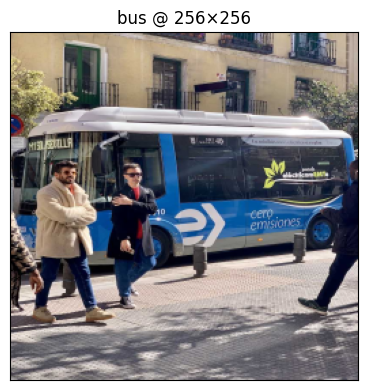

In [35]:
def load_image(path, size=256):
    '''Read an image, resize to (size, size), return both an HxWx3 uint8 array and an
    image tensor shaped (1, 3, H, W) on `device`.'''
    bgr = cv2.imread(str(path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_AREA)
    tensor = torch.tensor(rgb.transpose(2, 0, 1)[None].astype(np.float32)).to(device)
    return rgb, tensor

bus_rgb, bus_t = load_image(BUS, size=256)
H, W = bus_rgb.shape[:2]
print('image:', bus_rgb.shape, 'tensor:', tuple(bus_t.shape))
show(bus_rgb, titles=['bus @ 256×256'])

center bias shape: (256, 256) · exp sums to 0.9999999999999998


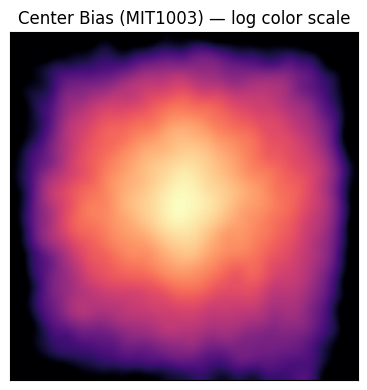

In [36]:
def build_centerbias(h, w, template_path=CB_PATH, uniform=False):
    '''Return a centerbias array of shape (h, w) as log-density (sums to 1 after exp).'''
    if uniform:
        cb = np.zeros((h, w), dtype=np.float64)
    else:
        template = np.load(template_path)
        cb = zoom(template, (h / template.shape[0], w / template.shape[1]),
                  order=0, mode='nearest')
    cb -= logsumexp(cb)  # normalise: exp(cb).sum() == 1
    return cb

cb = build_centerbias(H, W)
cb_t = torch.tensor(cb[None].astype(np.float32)).to(device)
print('center bias shape:', cb.shape, '· exp sums to', float(np.exp(cb).sum()))
# Show with a LogNorm colormap on the linear prior — the bowl shape is sharp at
# the centre and dim at the edges; in linear scale the periphery looks black,
# log colormapping spreads the falloff so the spatial structure is visible.
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(np.exp(cb), cmap='magma', norm=prob_norm(np.exp(cb), decades=2))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Center Bias (MIT1003) — log color scale')
plt.tight_layout(); plt.show()


In [37]:
print('Loading DeepGaze III pretrained weights (one-time download ~80 MB) ...')
model = deepgaze_pytorch.DeepGazeIII(pretrained=True).to(device).eval()
print('model loaded; included_fixations =', model.included_fixations)

Loading DeepGaze III pretrained weights (one-time download ~80 MB) ...


Using cache found in C:\Users\paple/.cache\torch\hub\pytorch_vision_v0.6.0


model loaded; included_fixations = [-1, -2, -3, -4]


log_density min/max: -25.76295 -6.5653434
probability sums to: 1.0000001


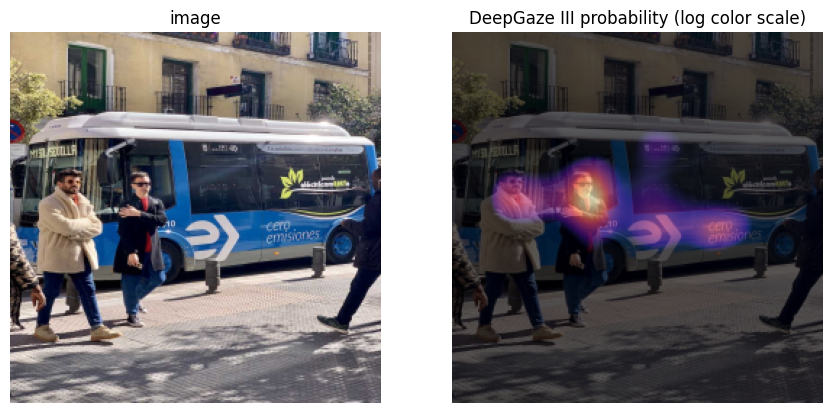

In [38]:
import torch.nn.functional as F

# DeepGaze III internal resolution. Kümmerer et al. 2022 (DeepGaze III,
# NeurIPS; doi:10.1167/jov.22.5.7) trained the DenseNet201 backbone at this scale.
DG_SIZE = 768  # DeepGaze sees the image at this resolution internally. At 256×256
               # DenseNet201's spatial features collapse to ~8×8 and the Finalizer's
               # gaussian washes the saliency map into a centre-bias-shaped blob; 768
               # is the smallest size on this image where windscreen / headlights /
               # pedestrians appear as distinct hot spots.

def deepgaze_density(image_tensor, centerbias_tensor, history_xy=None):
    '''Run DeepGaze III. Image and centerbias come in at (H, W); we lift them to
    DG_SIZE internally and aggregate the resulting probability back to (H, W) by
    area-pooling so it still sums to 1.

    `history_xy` is in (H, W) coords. Missing slots are filled with NaN so
    FlexibleScanpathHistoryEncoding deactivates them — padding with centre coords
    instead injects a spurious "user has been staring at the centre" signal into
    the scanpath network and the heatmap collapses onto the centre bias.'''
    B, _, h, w = image_tensor.shape
    image_dg = F.interpolate(image_tensor, size=(DG_SIZE, DG_SIZE),
                             mode='bilinear', align_corners=False)
    cb_dg = F.interpolate(centerbias_tensor[:, None], size=(DG_SIZE, DG_SIZE),
                          mode='bilinear', align_corners=False)[:, 0]
    cb_dg = cb_dg - torch.logsumexp(cb_dg.reshape(B, -1), dim=1).view(B, 1, 1)

    scale = DG_SIZE / w
    if not history_xy:
        history_xy = [(w // 2, h // 2)]
    nan = float('nan')
    history_dg = [(x * scale, y * scale) for (x, y) in history_xy]
    padded = [(nan, nan)] * (4 - len(history_dg)) + list(history_dg[-4:])
    xs = np.array([[p[0] for p in padded]], dtype=np.float32)
    ys = np.array([[p[1] for p in padded]], dtype=np.float32)
    xh = torch.tensor(xs[:, model.included_fixations]).to(device)
    yh = torch.tensor(ys[:, model.included_fixations]).to(device)
    with torch.no_grad():
        log_dens_dg = model(image_dg, cb_dg, xh, yh)            # (B, 1, DG, DG)
    p_dg = torch.exp(log_dens_dg)
    p_h = F.adaptive_avg_pool2d(p_dg, (h, w)) * (DG_SIZE * DG_SIZE) / (h * w)
    p_h = p_h / p_h.sum(dim=(2, 3), keepdim=True)
    return torch.log(p_h.clamp_min(1e-30)).squeeze().detach().cpu().numpy()  # (H, W)

log_d = deepgaze_density(bus_t, cb_t, history_xy=None)
prob = np.exp(log_d)
prob /= prob.sum()
print('log_density min/max:', log_d.min(), log_d.max())
print('probability sums to:', prob.sum())

# Display the linear probability with a LogNorm colormap. Raw imshow on the
# linear map saturates the colormap on the argmax and looks black everywhere
# else; LogNorm spreads the top ~2 decades of probability mass so secondary
# modes (other plausible fixations) become visible without the centre-bias
# bowl swallowing the picture (which would happen if we displayed log_d
# directly — log(saliency × CB) = log(saliency) + log(CB), and the CB term
# is what'd dominate visually).
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
axes[0].imshow(bus_rgb); axes[0].set_title('image'); axes[0].axis('off')
axes[1].imshow(bus_rgb); axes[1].imshow(prob, cmap='magma', norm=prob_norm(prob), alpha=0.65)
axes[1].set_title('DeepGaze III probability (log color scale)'); axes[1].axis('off')
plt.tight_layout(); plt.show()


**A note on what we just computed.** Each pixel of the probability map says how likely the
next fixation lands there. The map is bigger and brighter near the bus's front windscreen
and the standing pedestrians — DeepGaze has learned that humans gravitate to faces, vehicles,
and high-contrast structure. The Center Bias contribution is the soft halo near the middle
that lifts the centre of the image even where content is sparse.

argmax fixation: (95, 115)
sampled fixation: (121, 117)


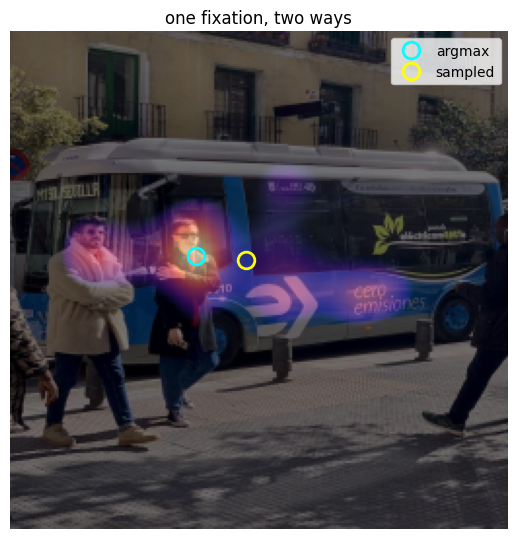

In [39]:
def sample_fixation(prob_map, rng=None):
    '''Sample one (x, y) point from a probability map (2D, sums to ~1).'''
    rng = rng or RNG
    flat = prob_map.ravel().astype(np.float64)
    flat /= flat.sum()
    idx = rng.choice(flat.size, p=flat)
    y, x = np.unravel_index(idx, prob_map.shape)
    return int(x), int(y)

x_arg, y_arg = np.unravel_index(prob.argmax(), prob.shape)[::-1]
x_smp, y_smp = sample_fixation(prob, np.random.default_rng(1))
print(f'argmax fixation: ({x_arg}, {y_arg})')
print(f'sampled fixation: ({x_smp}, {y_smp})')

# Linear probability + LogNorm colormap (see previous cell for why).
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(bus_rgb); ax.imshow(prob, cmap='magma', norm=prob_norm(prob), alpha=0.55)
ax.plot(x_arg, y_arg, 'o', color='cyan', ms=12, mfc='none', mew=2, label='argmax')
ax.plot(x_smp, y_smp, 'o', color='yellow', ms=12, mfc='none', mew=2, label='sampled')
ax.legend(loc='upper right'); ax.axis('off'); ax.set_title('one fixation, two ways')
plt.tight_layout(); plt.show()


### Exercise 1.1 — uniform vs MIT1003 Center Bias `[easy]`

Replace the MIT1003 Center Bias with a **uniform** prior and replot the probability map.
What changes, and what does that tell you about how much the page's "humans fixate near
the centre" prior was actually contributing?

*Hint: `build_centerbias(H, W, uniform=True)`.*

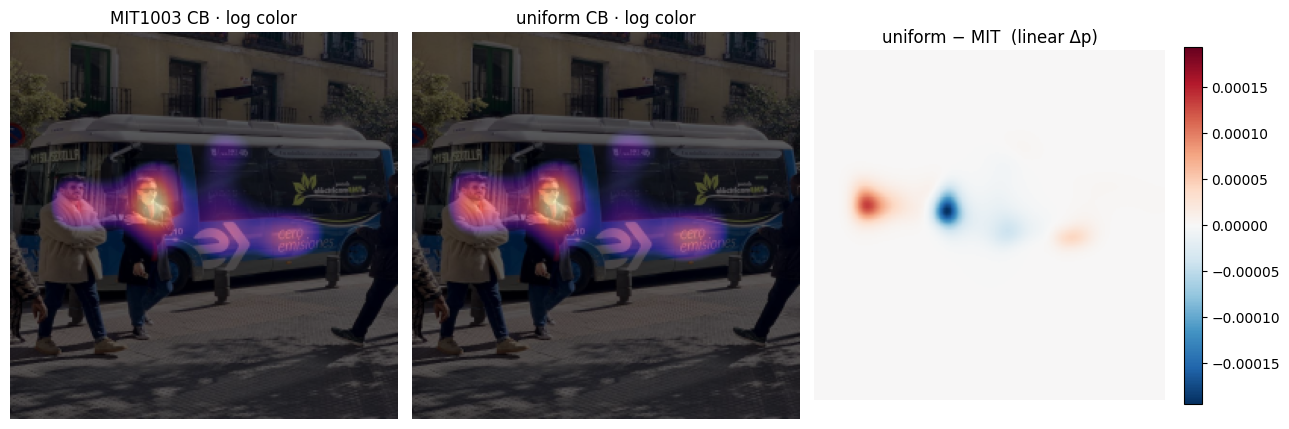

Pearson r between the two prob maps: 0.9881
argmax  MIT: (np.int64(95), np.int64(115))
argmax  uni: (np.int64(94), np.int64(115))


In [40]:
# Exercise 1.1 — uniform Center Bias
cb_uniform = build_centerbias(H, W, uniform=True)
cb_uniform_t = torch.tensor(cb_uniform[None].astype(np.float32)).to(device)
log_d_u = deepgaze_density(bus_t, cb_uniform_t)
prob_u = np.exp(log_d_u); prob_u /= prob_u.sum()

# Heatmaps in linear probability + LogNorm colormap so secondary modes are visible.
# Third panel is the linear probability difference — signed mass movement.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(bus_rgb); axes[0].imshow(prob,   cmap='magma', norm=prob_norm(prob),   alpha=0.65)
axes[0].set_title('MIT1003 CB · log color'); axes[0].axis('off')
axes[1].imshow(bus_rgb); axes[1].imshow(prob_u, cmap='magma', norm=prob_norm(prob_u), alpha=0.65)
axes[1].set_title('uniform CB · log color'); axes[1].axis('off')
diff = prob_u - prob
vlim = float(np.abs(diff).max())
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=-vlim, vmax=vlim)
axes[2].set_title('uniform − MIT  (linear Δp)'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()

print(f'Pearson r between the two prob maps: {np.corrcoef(prob.ravel(), prob_u.ravel())[0,1]:.4f}')
print(f'argmax  MIT: {np.unravel_index(prob.argmax(),   prob.shape)[::-1]}')
print(f'argmax  uni: {np.unravel_index(prob_u.argmax(), prob_u.shape)[::-1]}')

# Reading the panels:
#   · log-color heatmaps now show the *shape* of the distribution, not just the peak —
#     bus front is brightest but pedestrians + bus body are clearly secondary modes.
#   · the diff panel is in linear Δp because that's the educationally meaningful quantity:
#     where uniform CB redistributes mass relative to MIT. The bus dominates regardless
#     (Pearson r ≈ 0.99) but uniform CB strips a small halo around the centre and lets a
#     bit more mass leak onto the pedestrians and the bus body. CB matters most on bare/
#     low-content scenes — try a sky photo and the halo difference is huge.


### Exercise 1.2 — argmax vs sampled fixation `[easy]`

You just saw the argmax and one sampled fixation differ. Sample **20 fixations from the
same probability map** (each independent — do not update the history) and overlay them on
the image. The argmax is a single deterministic point; the sample is a distribution. The
cloud you produce here is the *distribution of plausible first looks*.

*Hint: call `sample_fixation` in a loop with different rng seeds.*

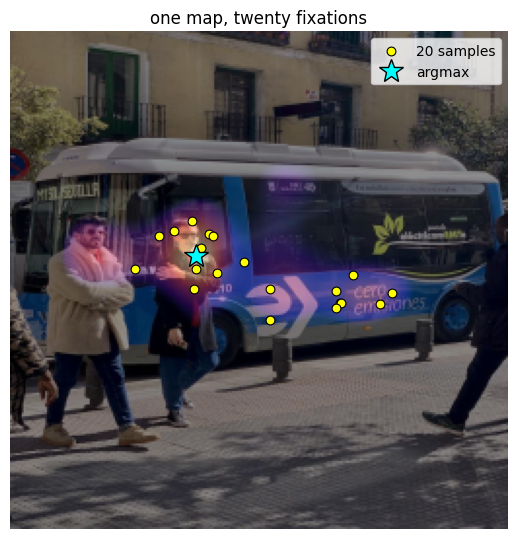

In [41]:
# Exercise 1.2 — 20 sampled fixations from the same probability map
xs, ys = [], []
for s in range(20):
    x, y = sample_fixation(prob, np.random.default_rng(100 + s))
    xs.append(x); ys.append(y)

# Heatmap overlay with LogNorm so the structure (not just the peak) is visible.
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(bus_rgb); ax.imshow(prob, cmap='magma', norm=prob_norm(prob), alpha=0.45)
ax.scatter(xs, ys, c='yellow', s=40, edgecolors='black', lw=0.8, label='20 samples')
ax.plot(x_arg, y_arg, '*', color='cyan', ms=18, mew=1, mec='black', label='argmax')
ax.legend(); ax.axis('off'); ax.set_title('one map, twenty fixations')
plt.tight_layout(); plt.show()


### Exercise 1.3 — does DeepGaze find the face? `[intermediate]`

Run DeepGaze III on the astronaut image and visualise the heatmap. Compare to the bus.
What happens to the probability mass when there's a face in the frame?

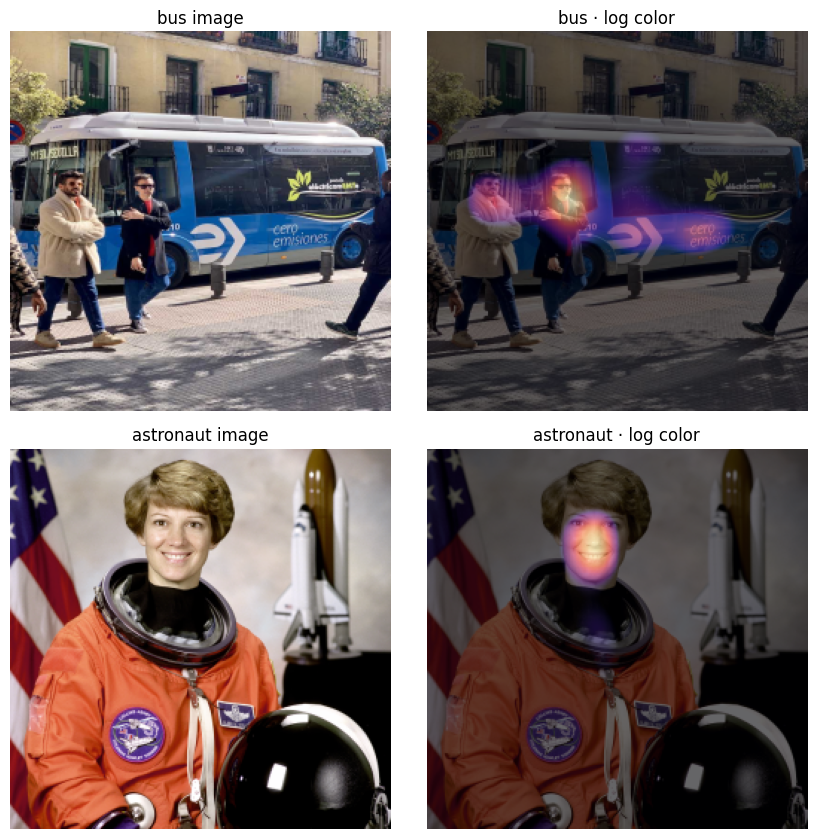

In [42]:
# Exercise 1.3 — astronaut (face) vs bus
face_rgb, face_t = load_image(FACE, size=256)
log_d_f = deepgaze_density(face_t, cb_t)
prob_f = np.exp(log_d_f); prob_f /= prob_f.sum()

# LogNorm colormaps on both probability maps so secondary modes are visible —
# on the face image especially, log color reveals how sharply the model
# concentrates mass on the eyes/visor over the rest of the helmet and shoulders.
fig, axes = plt.subplots(2, 2, figsize=(8.5, 8.5))
axes[0,0].imshow(bus_rgb); axes[0,0].set_title('bus image'); axes[0,0].axis('off')
axes[0,1].imshow(bus_rgb); axes[0,1].imshow(prob, cmap='magma', norm=prob_norm(prob), alpha=0.6)
axes[0,1].set_title('bus · log color'); axes[0,1].axis('off')
axes[1,0].imshow(face_rgb); axes[1,0].set_title('astronaut image'); axes[1,0].axis('off')
axes[1,1].imshow(face_rgb); axes[1,1].imshow(prob_f, cmap='magma', norm=prob_norm(prob_f), alpha=0.6)
axes[1,1].set_title('astronaut · log color'); axes[1,1].axis('off')
plt.tight_layout(); plt.show()

# Faces dominate the probability map — particularly the eyes and helmet visor. On the bus
# image, mass is spread across pedestrian heads, the windscreen,
# and high-contrast edges. The face image is much more concentrated.


## 2 · Sampling scanpaths + statistics  *(real-Python version of HTML §05 + §06)*

One fixation is not a scanpath. To get a sequence: sample, update the history, re-run the
model, sample again. Repeat. The model's *output map* changes at every step — the recently
visited spots get suppressed (inhibition of return) and the surrounding region brightens.

`sample_scanpath()` below is the literal pseudocode from HTML §05.

In [43]:
def sample_scanpath(image_tensor, cb_tensor, n_fix=12, seed=0, start_xy=None):
    '''Run DeepGaze III repeatedly, sampling one fixation per step. Returns the
    scanpath and the per-step (linear) probability map — `plot_scanpath` overlays
    it through a LogNorm colormap so the dynamic range is visible.'''
    rng = np.random.default_rng(seed)
    _, _, h, w = image_tensor.shape
    history = [start_xy or (w // 2, h // 2)]
    densities = []
    for _ in range(n_fix):
        log_d = deepgaze_density(image_tensor, cb_tensor, history)
        p = np.exp(log_d); p /= p.sum()
        densities.append(p)
        x, y = sample_fixation(p, rng)
        history.append((x, y))
    return history[1:], densities   # drop the seed centre fixation

path, densities = sample_scanpath(bus_t, cb_t, n_fix=12, seed=0)
print('scanpath length:', len(path))
print('first few fixations:', path[:4])


scanpath length: 12
first few fixations: [(49, 122), (90, 107), (161, 74), (130, 36)]


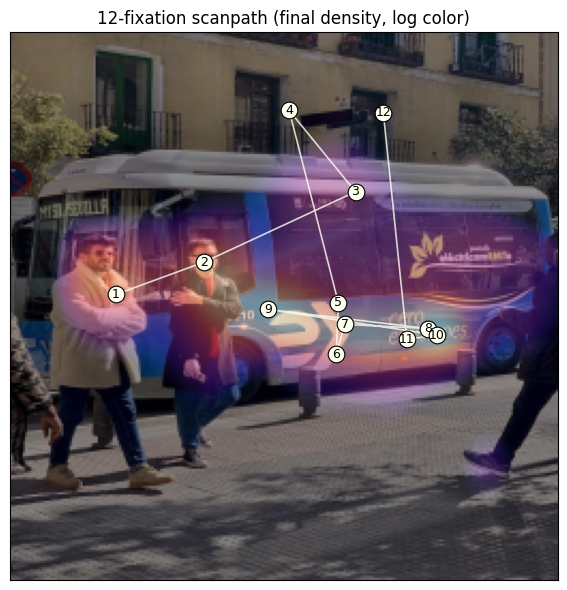

In [44]:
def plot_scanpath(image, path, density=None, ax=None, title=None):
    '''Plot a scanpath on top of an image. `density` should be a linear probability
    map — we apply a LogNorm colormap internally to compress the dynamic range.'''
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image)
    if density is not None:
        ax.imshow(density, cmap='magma', norm=prob_norm(density), alpha=0.45)
    xs = [p[0] for p in path]; ys = [p[1] for p in path]
    ax.plot(xs, ys, '-', color='ivory', lw=1.2, alpha=0.8)
    for i, (x, y) in enumerate(path, 1):
        ax.plot(x, y, 'o', color='ivory', mec='black', mew=0.8, ms=12)
        ax.text(x, y, str(i), color='black', ha='center', va='center', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title)

plot_scanpath(bus_rgb, path, densities[-1], title='12-fixation scanpath (final density, log color)')
plt.tight_layout(); plt.show()


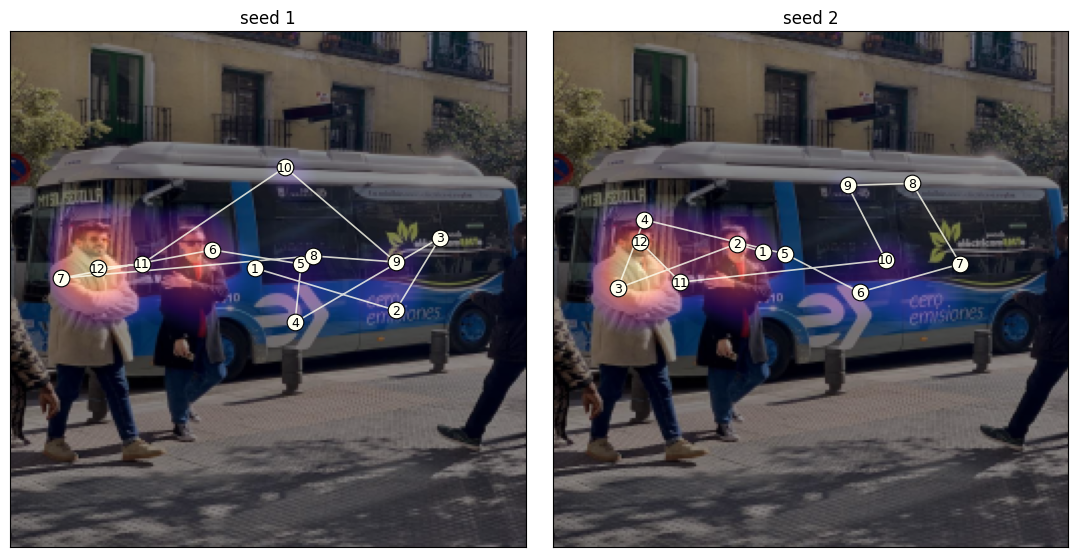

In [45]:
# "Run play twice. Same scanpath?" — two seeds side by side.
path_a, dens_a = sample_scanpath(bus_t, cb_t, n_fix=12, seed=1)
path_b, dens_b = sample_scanpath(bus_t, cb_t, n_fix=12, seed=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
plot_scanpath(bus_rgb, path_a, dens_a[-1], ax=axes[0], title='seed 1')
plot_scanpath(bus_rgb, path_b, dens_b[-1], ax=axes[1], title='seed 2')
plt.tight_layout(); plt.show()

The two scanpaths visit overlapping regions (both stop on the bus front and on a
pedestrian) but differ in order and exact landing points. That's the whole point of
sampling — DeepGaze gives you a *distribution* over plausible viewers, not a single canonical
trace.

### Exercise 2.1 — saccade-length distribution `[easy]`

Run 50 scanpaths of length 8 each on the bus and pool all the saccade lengths (Euclidean
distance between consecutive fixations). Plot a histogram. Compare to the HTML §06
saccade-length distribution — it should be skewed: many short jumps, fewer long ones.

*Hint: 50 × 8 = 400 saccades is plenty. Use different seeds, then `np.hypot` for distances.*

n saccades: 350, mean: 60.1px, median: 55.0px


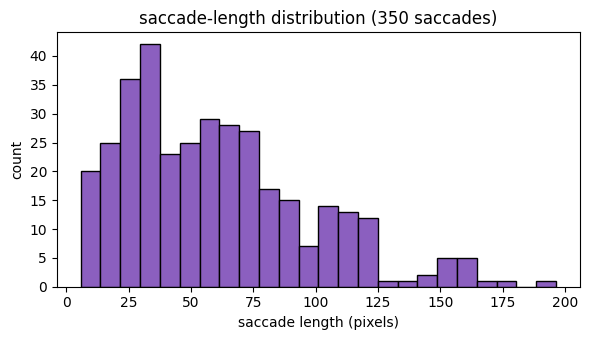

In [46]:
# Exercise 2.1 — saccade-length histogram across 50 scanpaths
lengths = []
for s in range(50):
    p, _ = sample_scanpath(bus_t, cb_t, n_fix=8, seed=10 + s)
    xs = np.array([f[0] for f in p]); ys = np.array([f[1] for f in p])
    dx = np.diff(xs); dy = np.diff(ys)
    lengths.extend(np.hypot(dx, dy).tolist())

print(f'n saccades: {len(lengths)}, mean: {np.mean(lengths):.1f}px, median: {np.median(lengths):.1f}px')
plt.figure(figsize=(6, 3.5))
plt.hist(lengths, bins=24, color='#8b5fbf', edgecolor='black')
plt.xlabel('saccade length (pixels)'); plt.ylabel('count')
plt.title(f'saccade-length distribution ({len(lengths)} saccades)')
plt.tight_layout(); plt.show()

### Exercise 2.2 — inhibition of return, empirically `[intermediate]`

Compare the probability map **before any fixation** vs **after one fixation at the
argmax**. Plot the *difference*. You should see a dark hole punched at and around the first
fixation, with brightness slightly redistributed to the periphery.

*Hint: `deepgaze_density(bus_t, cb_t, history_xy=None)` for the "before" map and
`deepgaze_density(bus_t, cb_t, history_xy=[(x_arg, y_arg)])` for "after". Plot
`after - before` with a diverging colormap.*

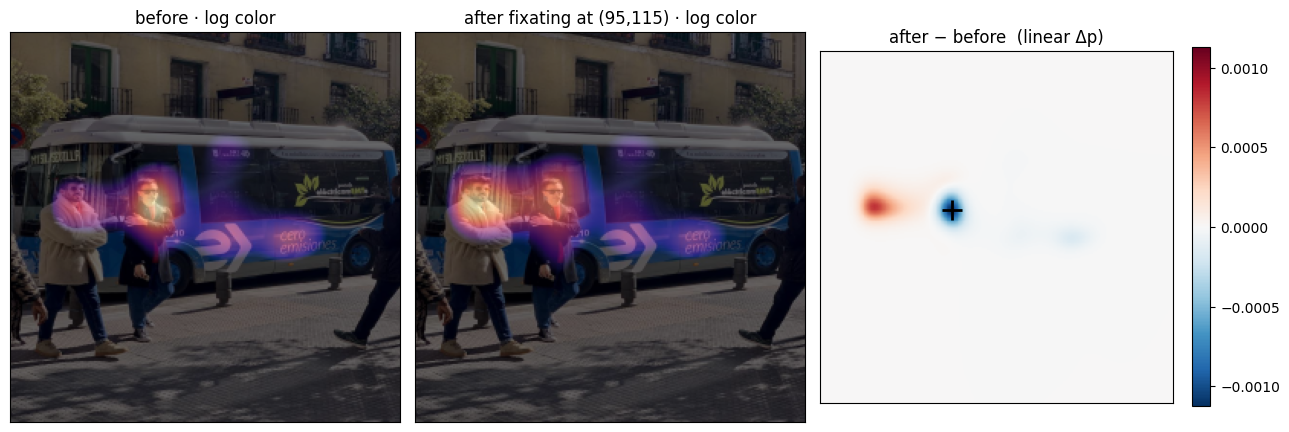

In [47]:
# Exercise 2.2 — heatmap before vs after the argmax fixation
log_before = deepgaze_density(bus_t, cb_t)
log_after  = deepgaze_density(bus_t, cb_t, history_xy=[(x_arg, y_arg)])
before = np.exp(log_before); before /= before.sum()
after  = np.exp(log_after);  after  /= after.sum()
diff = after - before

# Before/after panels use LogNorm colormaps so the IoR ring (mass redistribution)
# is visible, not just the suppressed peak. The diff panel stays linear because
# signed mass movement is the educationally meaningful quantity.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(bus_rgb); axes[0].imshow(before, cmap='magma', norm=prob_norm(before), alpha=0.6); axes[0].set_title('before · log color')
axes[1].imshow(bus_rgb); axes[1].imshow(after,  cmap='magma', norm=prob_norm(after),  alpha=0.6); axes[1].set_title(f'after fixating at ({x_arg},{y_arg}) · log color')
vlim = float(np.abs(diff).max())
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=-vlim, vmax=vlim)
axes[2].plot(x_arg, y_arg, '+', color='black', ms=14, mew=2)
axes[2].set_title('after − before  (linear Δp)')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()


### Exercise 2.3 — saccade angles `[intermediate]`

Compute the **angle of each saccade relative to the previous one** (in radians) across many
scanpaths and histogram it. Real humans (and DeepGaze) keep going in roughly the same
direction more often than they double back — you should see a bump near 0 and dips near ±π.

*Hint: for three consecutive fixations A→B→C, the turn angle is `atan2(C.y-B.y, C.x-B.x) -
atan2(B.y-A.y, B.x-A.x)`, wrapped into (-π, π].*

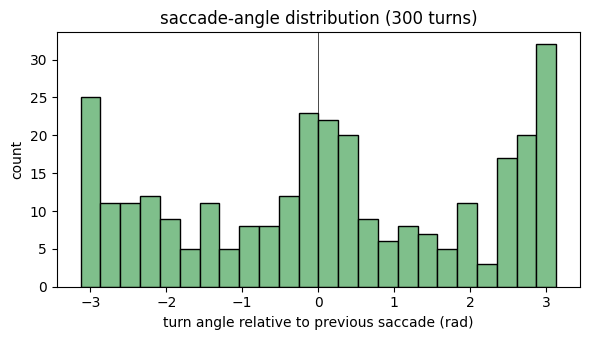

In [48]:
# Exercise 2.3 — saccade-angle histogram across 50 scanpaths
angles = []
for s in range(50):
    p, _ = sample_scanpath(bus_t, cb_t, n_fix=8, seed=200 + s)
    p = np.array(p)
    if len(p) < 3:
        continue
    v = np.diff(p, axis=0)               # saccade vectors (n-1, 2)
    a = np.arctan2(v[:, 1], v[:, 0])     # heading per saccade
    da = np.diff(a)                      # turn angle between consecutive saccades
    da = (da + np.pi) % (2 * np.pi) - np.pi
    angles.extend(da.tolist())

plt.figure(figsize=(6, 3.5))
plt.hist(angles, bins=24, color='#7fbf8b', edgecolor='black')
plt.xlabel('turn angle relative to previous saccade (rad)')
plt.ylabel('count'); plt.title(f'saccade-angle distribution ({len(angles)} turns)')
plt.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()

## 3 · Phosphene rendering with `dynaphos`

So far we have not touched a phosphene. Time to plug a real simulator in.

[`dynaphos`](https://github.com/neuralcodinglab/dynaphos) (van der Grinten et al., *eLife*
2024) is a biologically grounded forward model of cortical phosphene perception. Each
electrode lives on the cortex; through a cortical-magnification mapping it projects to a
*phosphene location* in the visual field. Stimulating an electrode produces a Gaussian
blob centred at that visual-field location whose brightness and size depend on the current
amplitude.

We embed the published `params.yaml` as a Python dict so you can see (and tweak) every
knob without leaving the notebook.

In [49]:
# Default dynaphos parameters (copy of config/params.yaml from neuralcodinglab/dynaphos,
# with `run.resolution` set to [256, 256] to match the image size we picked in §0).
DYNAPHOS_PARAMS = {
    'run': {
        'resolution': [256, 256], 'view_angle': 16, 'origin': [0, 0],
        'min_angle': 0.001, 'fps': 35, 'gpu': 0, 'print_stats': False,
        'seed': 42, 'dtype': 'float32', 'use_gaussian_lut': False, 'batch_size': 0,
    },
    'display': {
        'screen_resolution': [1920, 1080], 'screen_diagonal': 13.3,
        'dist_to_screen': 600,
    },
    'sampling': {
        'sampling_method': 'receptive_fields', 'RF_size': 0.5,
        'stimulus_scale': 1.0e-4,
    },
    'cortex_model': {
        'model': 'dipole', 'k': 17.3, 'a': 0.75, 'b': 120, 'alpha': 0.95,
        'dropout_rate': 0.2, 'noise_scale': 0.4,
    },
    'temporal_dynamics': {
        'trace_increase_rate': 13.95528162,
        'activation_decay_per_second': 0.00012340980408667956,
        'trace_decay_per_second': 0.99949191,
    },
    'size': {
        'size_equation': 'sqrt', 'MD': 0.7, 'I_half': 40, 'slope_size': 0.08,
        'current_spread': 6.75e-4, 'radius_to_sigma': 0.5,
    },
    'brightness_saturation': {
        'cps_half': 1.057631326853325e-07,
        'slope_brightness': 19152642.500946816,
    },
    'thresholding': {
        'use_threshold': True, 'rheobase': 2.39e-5,
        'activation_threshold': 9.141886000943878e-08,
        'activation_threshold_sd': 6.715877869833961e-08,
    },
    'default_stim': {
        'relative_stim_duration': 1, 'pw_default': 1.7e-4, 'freq_default': 300,
    },
    'gabor': {'gabor_filtering': False, 'gamma': 1.5},
}

def make_simulator(n_phosphenes=500, seed=0, params=None):
    p = params or DYNAPHOS_PARAMS
    rng = np.random.default_rng(seed)
    coords = get_visual_field_coordinates_probabilistically(p, n_phosphenes, rng=rng)
    sim = GaussianSimulator(p, coords, rng=rng)
    sim._coords = coords   # keep the Map handy for inspection (not stored by dynaphos)
    return sim

sim = make_simulator(n_phosphenes=500)
xs_vf, ys_vf = sim._coords.cartesian
print(f'simulator built · {sim.num_phosphenes} phosphenes · '
      f'visual-field x range [{xs_vf.min():+.1f}, {xs_vf.max():+.1f}] deg')

simulator built · 500 phosphenes · visual-field x range [-7.6, +7.5] deg


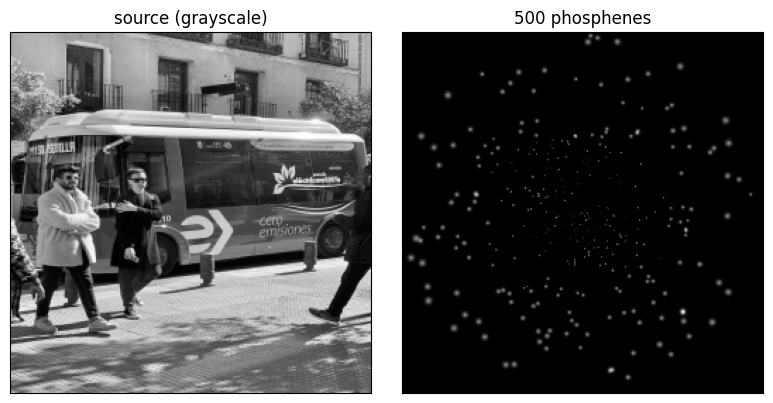

In [50]:
def render_phosphenes(sim, image_2d):
    '''Apply `dynaphos` to a 2D image and return the rendered phosphene image.'''
    if image_2d.dtype != np.float32:
        image_2d = image_2d.astype(np.float32)
    if image_2d.max() > 1.5:
        image_2d = image_2d / 255.0
    sim.reset()
    stim = sim.sample_stimulus(image_2d, rescale=True)
    sim.update(amplitude=stim)
    activations = sim.gaussian_activation()                # (n_phos, H, W)
    return activations.sum(0).detach().cpu().numpy()        # (H, W)

bus_gray = cv2.cvtColor(bus_rgb, cv2.COLOR_RGB2GRAY)
phos = render_phosphenes(sim, bus_gray)
show(bus_gray, phos, titles=['source (grayscale)', f'500 phosphenes'], cmap='gray')

### Exercise 3.1 — bandwidth vs picture quality `[easy]`

A real cortical implant has ~100–1000 electrodes. Render the same bus image at 100, 500,
and 1000 phosphenes and plot them side by side. Where is the elbow — at what electrode
count does the bus become recognisable?

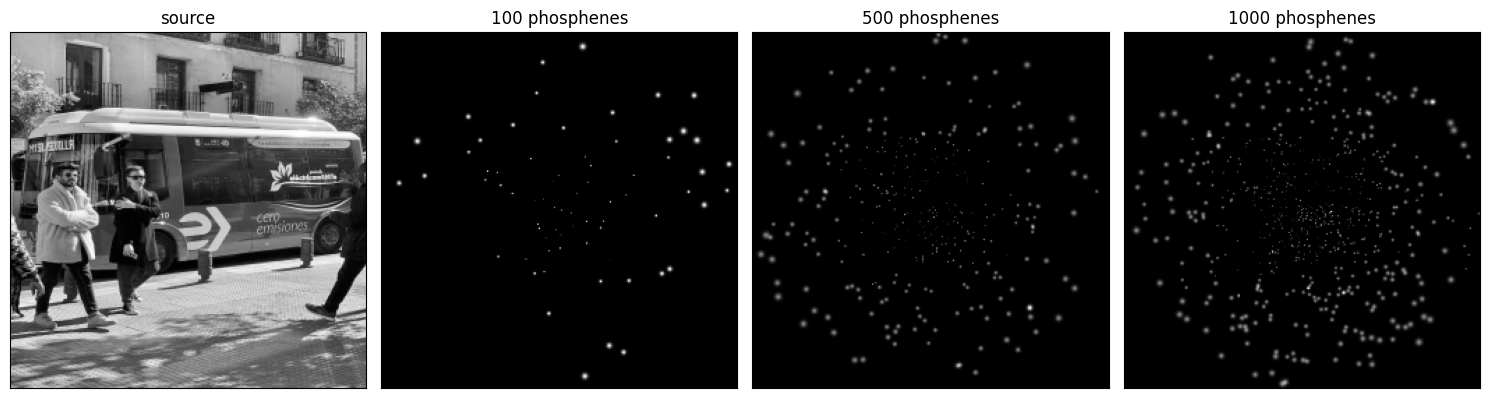

In [51]:
# Exercise 3.1 — vary electrode count
images, titles = [bus_gray], ['source']
for n in (100, 500, 1000):
    s = make_simulator(n_phosphenes=n, seed=0)
    images.append(render_phosphenes(s, bus_gray))
    titles.append(f'{n} phosphenes')
show(*images, titles=titles, cmap='gray', figsize=(15, 4.2))

### Exercise 3.2 — what does an edge map look like through phosphenes? `[intermediate]`

`dynaphos` ships with a Sobel processor (`sobel_processor`) — the same idea as the M1
edge detector. Pass the **edge map** of the bus through phosphenes instead of raw
intensities. Sparse edges + sparse phosphenes is the realistic prosthesis pipeline; raw
intensity is a sanity baseline.

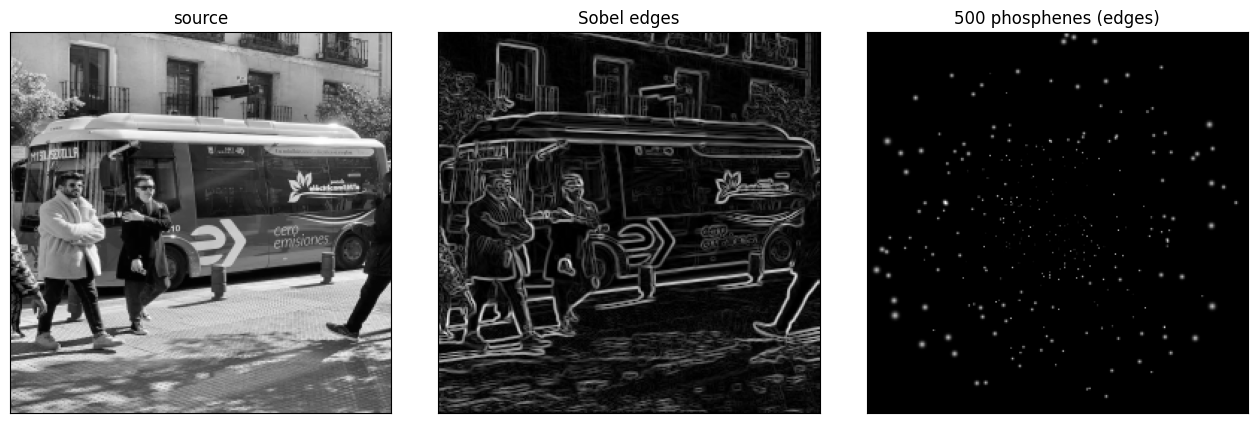

In [52]:
# Exercise 3.2 — edge map → phosphenes
edges = sobel_processor(bus_gray.astype(np.float32))
edges_norm = edges / max(edges.max(), 1e-6)
sim500 = make_simulator(n_phosphenes=500, seed=0)
phos_edges = render_phosphenes(sim500, edges_norm)

show(bus_gray, edges_norm, phos_edges,
     titles=['source', 'Sobel edges', '500 phosphenes (edges)'], cmap='gray', figsize=(13, 4.2))

## 4 · Gaze + phosphenes — what the user actually sees

So far, two halves of the loop: DeepGaze picking *where* to look, dynaphos
turning a single frame into a phosphene image. A real prosthesis user lives in
the continuous version of that — fixate somewhere, get a phosphene snapshot of
the foveated patch, saccade, get the next snapshot, integrate. Across ~10–20
fixations their brain builds up an internal picture of the scene: sparse,
biased toward whatever attention chose to land on, capped by phosphene
bandwidth at every step.

This section simulates that picture. We **walk a scanpath through the simulator
one fixation at a time** and accumulate the per-fixation phosphenes into a
running canvas — a stand-in for "what the user has seen so far". The result
depends on:

- the fixation strategy (DeepGaze vs random vs a regular grid),
- how many fixations you spend,
- and — Exercise 4.3 — which metric you use to judge the result.

**§4a — The sliding effect.** A qualitative warm-up. Each phosphene is locked
to a position in the *visual field*, not in the world; a naïve renderer that
ignores gaze would feel like the entire scene drags across the user's eye on
every saccade. Gaze-contingent rendering re-centres the world on the current
fixation so the attended patch lands on the fovea and the rest of the world
stays put.

**§4b — Cumulative reconstruction.** Quantitative. Walk the scanpath,
accumulate the phosphenes, and measure how close the running canvas gets to
the original scene as a function of scanpath length × strategy. Pearson r and
SSIM are the default measuring sticks — Exercise 4.3 asks whether they're the
*right* ones for modelling what the user perceives.

### 4a · The sliding effect

The user's gaze always lands at the centre of *their* visual field — that's where the fovea
is. So the prosthesis needs to render the world such that whatever the user is looking at
ends up at the centre of the phosphene grid. We implement this with a `foveate` helper:
given the camera frame + a fixation point, it returns a centred view of the world around
that fixation, dark outside a "useful field of view" radius.

demo fixations: [(49, 122), (130, 36), (156, 136), (199, 141)]


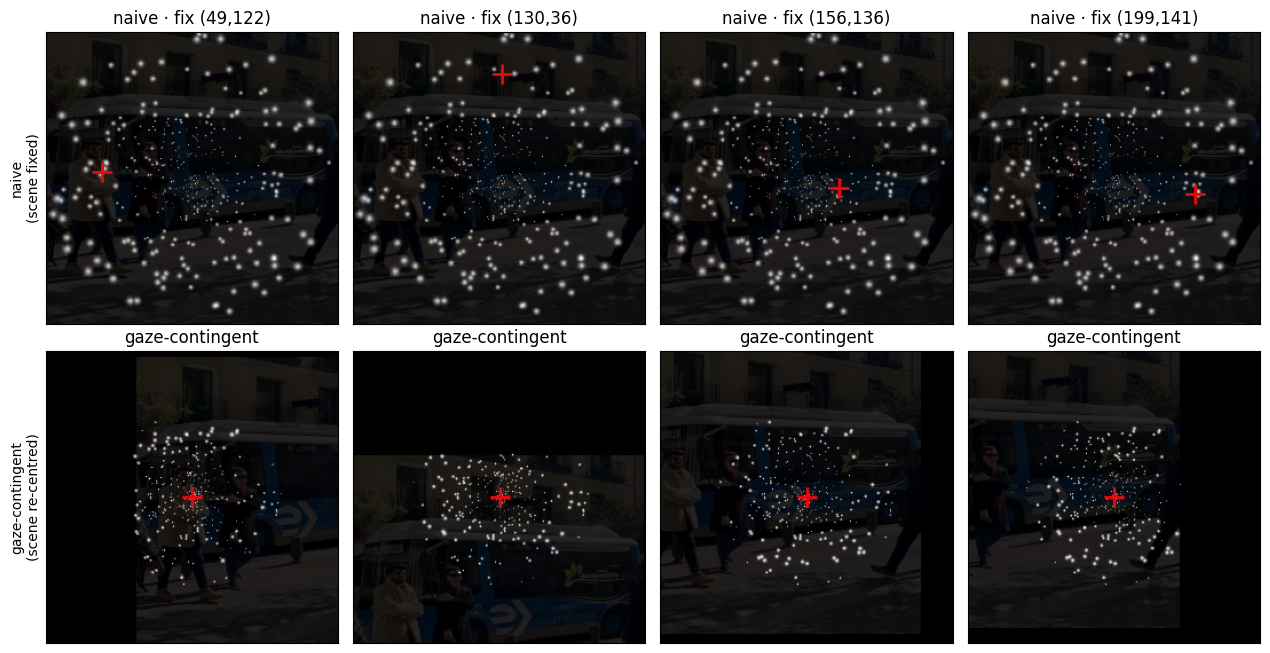

In [69]:
def foveate(image, xy, fov_radius=64, output_size=None):
    '''Translate `image` so that `xy` is at the centre, then mask to a soft disc.'''
    if image.ndim == 3:
        h, w, _ = image.shape
    else:
        h, w = image.shape
    output_size = output_size or (h, w)
    th, tw = output_size
    fx, fy = xy
    # Shift so (fx, fy) lands at (tw/2, th/2)
    M = np.float32([[1, 0, tw / 2 - fx], [0, 1, th / 2 - fy]])
    shifted = cv2.warpAffine(image, M, (tw, th), borderValue=0)
    # Soft circular mask
    yy, xx = np.ogrid[:th, :tw]
    r = np.hypot(xx - tw / 2, yy - th / 2)
    mask = np.clip(1.0 - (r - fov_radius) / 12.0, 0, 1)
    if shifted.ndim == 3:
        mask = mask[..., None]
    return (shifted.astype(np.float32) * mask).astype(shifted.dtype)

def _recentre(image, xy):
    '''Translate `image` so `xy` lands at the centre, no masking — used as
    the faint underlay in the adaptive panels.'''
    h, w = image.shape[:2]
    M = np.float32([[1, 0, w / 2 - xy[0]], [0, 1, h / 2 - xy[1]]])
    return cv2.warpAffine(image, M, (w, h), borderValue=0)

def _phosphene_rgba(phos, gamma=0.45):
    '''Render a phosphene image as a pure-white RGBA overlay. Per-pixel alpha
    = (phos/peak)**gamma; gamma<1 lifts midtones so each Gaussian blob reads as
    an opaque white core, not the muddy gray you get from cmap='gray' + alpha.'''
    m = float(phos.max())
    rgba = np.zeros((*phos.shape, 4), dtype=np.float32)
    if m > 0:
        rgba[..., :3] = 1.0  # pure white
        rgba[..., 3] = np.clip(phos / m, 0, 1) ** gamma
    return rgba

# Take 4 evenly-spaced fixations from the seed-0 scanpath we already have
sample_idx = [0, 3, 6, 9]
fixations = [path[i] for i in sample_idx]
print('demo fixations:', fixations)

sim_demo = make_simulator(n_phosphenes=500, seed=0)
# Naive rendering is gaze-independent → render once. We push it through
# `foveate` with a centre fixation and a large radius (covers the whole frame
# but with the same soft edge the adaptive path uses) so dynaphos sees a
# comparably-shaped input in both cases — that keeps per-phosphene currents,
# and therefore blob sizes, matched between the rows.
naive = render_phosphenes(sim_demo, foveate(bus_gray, (W // 2, H // 2),
                                            fov_radius=int(0.55 * min(H, W))))

# UNDERLAY_ALPHA controls bus visibility only. 0 → bus invisible (phosphenes
# alone on a black canvas); 1 → bus fully opaque with phosphenes drawn on top.
UNDERLAY_ALPHA = 0.15

fig, axes = plt.subplots(2, len(fixations), figsize=(3.2 * len(fixations), 6.6))
for j, (fx, fy) in enumerate(fixations):
    foved = foveate(bus_gray, (fx, fy), fov_radius=64)
    smart = render_phosphenes(sim_demo, foved)

    # naive row: world stays anchored; gaze marker drifts across it
    # Black facecolor so UNDERLAY_ALPHA=0 falls back to black, not the axes' default white
    # (with a white default, the phosphenes — also white — would disappear into the bleed-through).
    axes[0, j].set_facecolor('black')
    axes[0, j].imshow(bus_rgb, alpha=UNDERLAY_ALPHA)
    axes[0, j].imshow(_phosphene_rgba(naive))
    axes[0, j].plot(fx, fy, '+', color='red', ms=14, mew=2)
    axes[0, j].set_title(f'naive · fix ({fx},{fy})')

    # adaptive row: world slides so (fx, fy) lands at panel centre
    axes[1, j].set_facecolor('black')
    axes[1, j].imshow(_recentre(bus_rgb, (fx, fy)), alpha=UNDERLAY_ALPHA)
    axes[1, j].imshow(_phosphene_rgba(smart))
    axes[1, j].plot(W / 2, H / 2, '+', color='red', ms=14, mew=2)
    axes[1, j].set_title('gaze-contingent')

    for ax in (axes[0, j], axes[1, j]):
        ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('naive\n(scene fixed)', fontsize=10)
axes[1, 0].set_ylabel('gaze-contingent\n(scene re-centred)', fontsize=10)
plt.tight_layout(); plt.show()


**What you should see.** Top row: the phosphene image is identical at every fixation,
because the naive renderer ignores gaze. The red `+` marks where the user is looking — and
it drifts across the rendered image. That's the sliding effect: the user perceives the
scene as anchored to *the eye*, not the world.

Bottom row: every frame re-centres the relevant patch of the world to the fovea. The user
"sees" what they're attending to, and everything outside their useful field of view is
dark. The cost is bandwidth — only a foveated patch is rendered, so we are betting the
attended region is the informative one. That's exactly what DeepGaze gives us a model of.

### 4b · Cumulative reconstruction — what's in the canvas after N fixations

For each fixation along a scanpath:

1. Take a **foveated view** of the world centred at that fixation — what the
   user's fovea is currently pointed at.
2. Pass it through `dynaphos` to get a phosphene image $P_i$, then re-shift it
   back to world coordinates so consecutive snapshots are spatially comparable.
3. **Accumulate** into a running canvas $C_i = \max(C_{i-1}, P_i)$ — per-pixel
   max keeps the brightest phosphene reading at each world location so far.
   $C_i$ is our proxy for the user's accumulated percept after $i$ fixations.
4. Plot $C_i$ at a few milestones, and quantify how close it has gotten to the
   original scene.

We compare three strategies: **DeepGaze** (informed attention), **uniform
random** fixations, and a **regular grid** scan. Pearson r and SSIM tell you
how much of the image you'd recover if you stared at the canvas — but a user
doesn't perceive "correlation with the ground truth", they perceive *the parts
of the world that matter*. Exercise 4.3 designs metrics that take that
seriously.

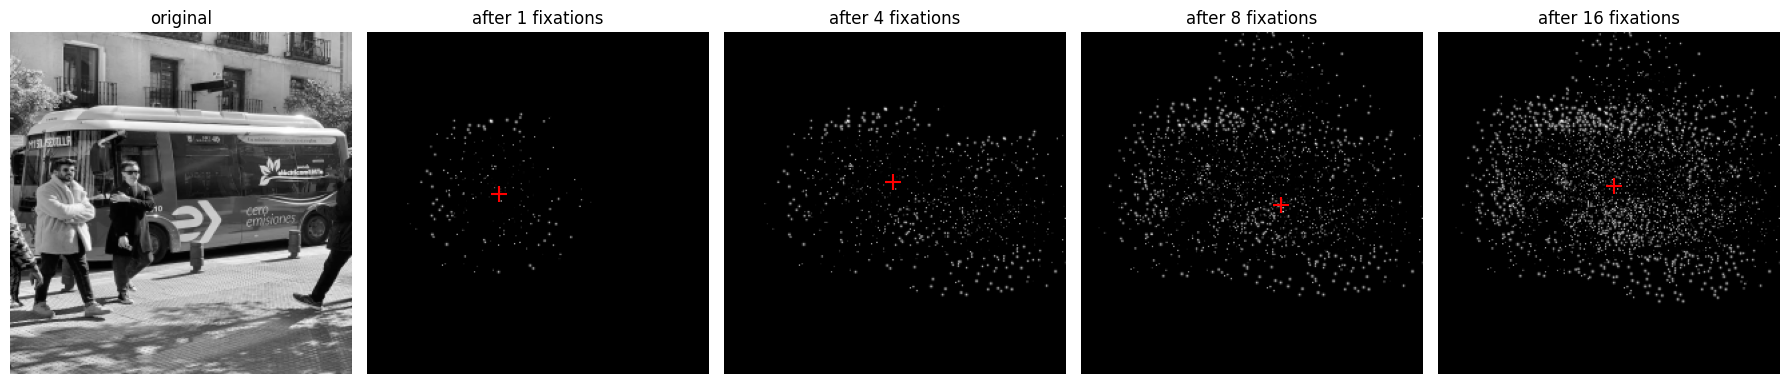

In [54]:
def accumulate(prev, new, mode='max'):
    if prev is None:
        return new.copy()
    if mode == 'max':
        return np.maximum(prev, new)
    if mode == 'sum':
        return prev + new
    if mode == 'mean':
        return None  # handled in the caller (needs a counter)
    raise ValueError(mode)

def walk(image_gray, scanpath, sim, fov_radius=64, mode='max'):
    '''Yield the cumulative reconstruction after each fixation.'''
    canvas = None
    history = []
    for xy in scanpath:
        foved = foveate(image_gray, xy, fov_radius=fov_radius)
        phos = render_phosphenes(sim, foved)
        # Re-shift the phosphene image so that the foveated patch sits where the eye was
        # — this puts P_i back in world coordinates.
        h, w = phos.shape
        M = np.float32([[1, 0, xy[0] - w / 2], [0, 1, xy[1] - h / 2]])
        phos_world = cv2.warpAffine(phos, M, (w, h), borderValue=0)
        canvas = accumulate(canvas, phos_world, mode=mode)
        history.append(canvas.copy())
    return history

# DeepGaze scanpath of 16 fixations
dg_path, _ = sample_scanpath(bus_t, cb_t, n_fix=16, seed=7)
sim4 = make_simulator(n_phosphenes=500, seed=0)
hist_dg = walk(bus_gray, dg_path, sim4, fov_radius=56)

milestones = [0, 3, 7, 15]
fig, axes = plt.subplots(1, len(milestones) + 1, figsize=(3.6 * (len(milestones)+1), 3.8))
axes[0].imshow(bus_gray, cmap='gray'); axes[0].set_title('original'); axes[0].axis('off')
for ax, i in zip(axes[1:], milestones):
    ax.imshow(hist_dg[i], cmap='gray')
    fx, fy = dg_path[i]
    ax.plot(fx, fy, '+', color='red', ms=12, mew=1.5)
    ax.set_title(f'after {i+1} fixations'); ax.axis('off')
plt.tight_layout(); plt.show()

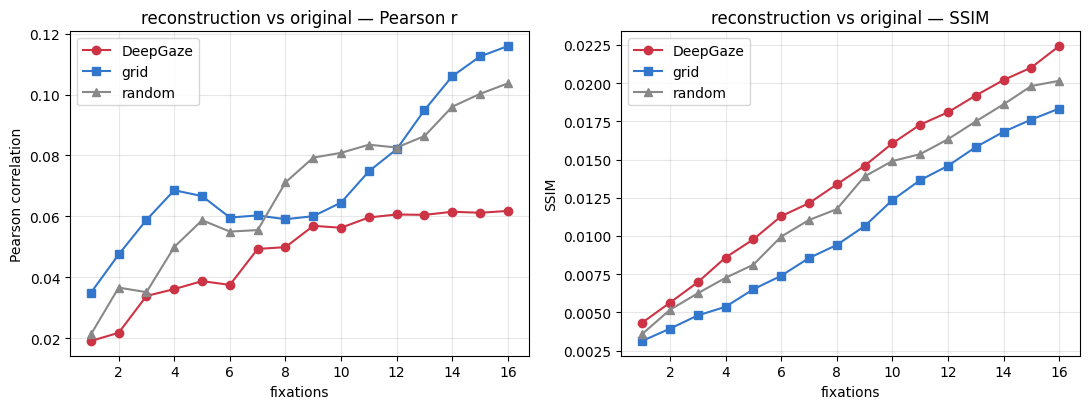

In [55]:
def similarity(reconstruction, target):
    a = reconstruction.astype(np.float32)
    b = target.astype(np.float32) / max(target.max(), 1e-6)
    if a.max() > 0:
        a = a / a.max()
    pearson = np.corrcoef(a.ravel(), b.ravel())[0, 1]
    ssim = ssim_metric(a, b, data_range=1.0)
    return pearson, ssim

def grid_scanpath(h, w, n):
    '''Snake-order grid of n fixations.'''
    side = int(np.ceil(np.sqrt(n)))
    xs = np.linspace(w * 0.15, w * 0.85, side)
    ys = np.linspace(h * 0.15, h * 0.85, side)
    pts = []
    for j, y in enumerate(ys):
        row = xs if j % 2 == 0 else xs[::-1]
        for x in row:
            pts.append((int(x), int(y)))
    return pts[:n]

def random_scanpath(h, w, n, seed=0):
    rng = np.random.default_rng(seed)
    return [(int(rng.uniform(w * 0.1, w * 0.9)),
             int(rng.uniform(h * 0.1, h * 0.9))) for _ in range(n)]

N_FIX = 16
sim_cmp = make_simulator(n_phosphenes=500, seed=0)
hist_grid   = walk(bus_gray, grid_scanpath(H, W, N_FIX), sim_cmp, fov_radius=56)
hist_random = walk(bus_gray, random_scanpath(H, W, N_FIX, seed=3), sim_cmp, fov_radius=56)

def curves(hist):
    pc, sc = [], []
    for c in hist:
        p, s = similarity(c, bus_gray)
        pc.append(p); sc.append(s)
    return np.array(pc), np.array(sc)

p_dg, s_dg   = curves(hist_dg)
p_gr, s_gr   = curves(hist_grid)
p_rn, s_rn   = curves(hist_random)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x_axis = np.arange(1, N_FIX + 1)
axes[0].plot(x_axis, p_dg, '-o', label='DeepGaze', color='#cc3344')
axes[0].plot(x_axis, p_gr, '-s', label='grid',     color='#3377cc')
axes[0].plot(x_axis, p_rn, '-^', label='random',   color='#888888')
axes[0].set_xlabel('fixations'); axes[0].set_ylabel('Pearson correlation')
axes[0].set_title('reconstruction vs original — Pearson r'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x_axis, s_dg, '-o', label='DeepGaze', color='#cc3344')
axes[1].plot(x_axis, s_gr, '-s', label='grid',     color='#3377cc')
axes[1].plot(x_axis, s_rn, '-^', label='random',   color='#888888')
axes[1].set_xlabel('fixations'); axes[1].set_ylabel('SSIM')
axes[1].set_title('reconstruction vs original — SSIM'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**What you should see.** DeepGaze typically rises faster than the random strategy on both
metrics — its first few fixations land on informative parts of the scene (the bus front,
pedestrians), so the cumulative reconstruction explains the variance of the original
faster. The regular grid is a strong baseline: by construction it covers the whole image
uniformly, so it tends to overtake DeepGaze once you have enough fixations to tile the
scene. The interesting regime is **few fixations** — where every saccade has to count, gaze
prediction is doing real work.

Try re-running the cell with a different DeepGaze seed; the curves are stochastic but the
ranking near the start is fairly stable on this image.

### Exercise 4.1 — visualise the build-up `[easy]`

Plot the cumulative reconstruction at $C_1$, $C_5$, $C_{15}$ for the DeepGaze
strategy with the scanpath laid on top. Which regions fill in first?

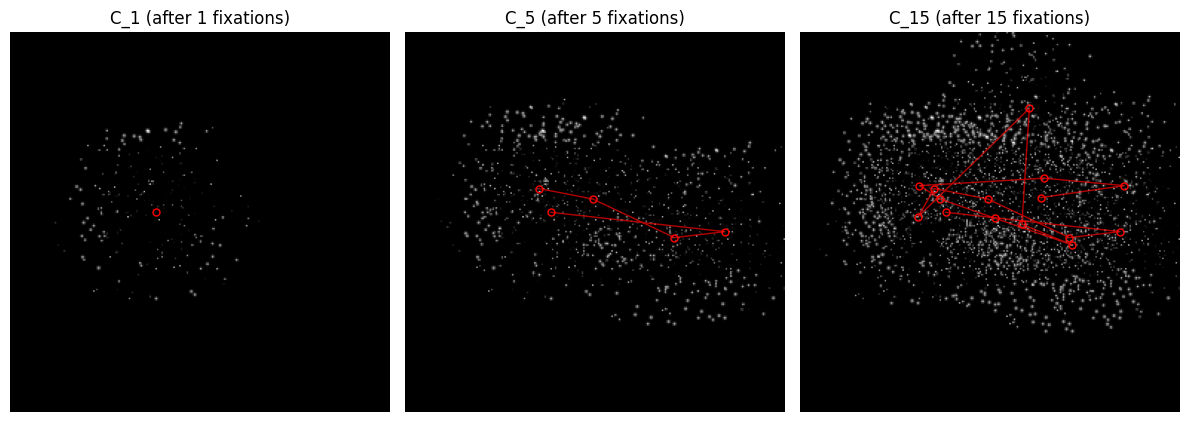

In [56]:
# Exercise 4.1 — DeepGaze build-up at milestones
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, i in zip(axes, [0, 4, 14]):
    ax.imshow(hist_dg[i], cmap='gray')
    xs = [p[0] for p in dg_path[:i+1]]; ys = [p[1] for p in dg_path[:i+1]]
    ax.plot(xs, ys, '-', color='red', lw=1, alpha=0.7)
    ax.plot(xs, ys, 'o', color='red', ms=5, mfc='none')
    ax.set_title(f'C_{i+1} (after {i+1} fixations)'); ax.axis('off')
plt.tight_layout(); plt.show()

### Exercise 4.2 — write your own `cumulative_similarity` `[intermediate]`

Write a function `cumulative_similarity(scanpath, image_gray, sim, fov_radius=56) -> (pearson, ssim)`
that runs `walk()` and returns the two arrays. Then reproduce the three-curve plot above
**on the astronaut image** rather than the bus. Does DeepGaze keep its early-fixation lead
when there is a face in the frame?

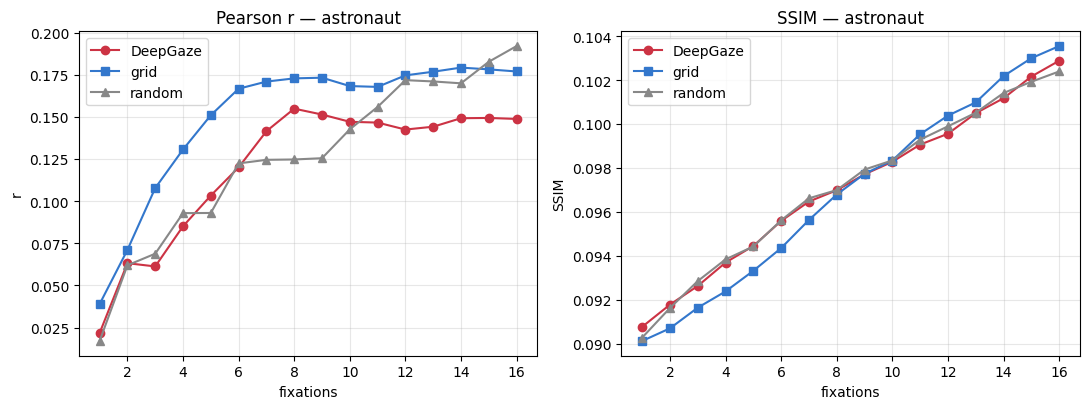

In [57]:
# Exercise 4.2 — cumulative_similarity on the astronaut
def cumulative_similarity(scanpath, image_gray, sim, fov_radius=56):
    hist = walk(image_gray, scanpath, sim, fov_radius=fov_radius)
    pc, sc = [], []
    for c in hist:
        p, s = similarity(c, image_gray)
        pc.append(p); sc.append(s)
    return np.array(pc), np.array(sc)

face_gray = cv2.cvtColor(face_rgb, cv2.COLOR_RGB2GRAY)
dg_face_path, _ = sample_scanpath(face_t, cb_t, n_fix=N_FIX, seed=4)
sim_face = make_simulator(n_phosphenes=500, seed=0)

p_dg_f, s_dg_f = cumulative_similarity(dg_face_path, face_gray, sim_face)
p_gr_f, s_gr_f = cumulative_similarity(grid_scanpath(H, W, N_FIX), face_gray, sim_face)
p_rn_f, s_rn_f = cumulative_similarity(random_scanpath(H, W, N_FIX, seed=5), face_gray, sim_face)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x_axis = np.arange(1, N_FIX + 1)
for vals, lbl, color, mk in [(p_dg_f, 'DeepGaze', '#cc3344', 'o'),
                              (p_gr_f, 'grid',     '#3377cc', 's'),
                              (p_rn_f, 'random',   '#888888', '^')]:
    axes[0].plot(x_axis, vals, '-'+mk, label=lbl, color=color)
for vals, lbl, color, mk in [(s_dg_f, 'DeepGaze', '#cc3344', 'o'),
                              (s_gr_f, 'grid',     '#3377cc', 's'),
                              (s_rn_f, 'random',   '#888888', '^')]:
    axes[1].plot(x_axis, vals, '-'+mk, label=lbl, color=color)
axes[0].set_title('Pearson r — astronaut'); axes[0].set_xlabel('fixations'); axes[0].set_ylabel('r'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('SSIM — astronaut'); axes[1].set_xlabel('fixations'); axes[1].set_ylabel('SSIM'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Exercise 4.3 — perceptual reconstruction metrics `[intermediate]`

Pearson r between the canvas and the original measures how strongly
corresponding pixel intensities co-vary. It treats every pixel equally, ignores
spatial structure, and is happy to declare two images "similar" as long as
their gross brightness patterns align. A human looking at the cumulative canvas
doesn't judge it that way:

- **They care about where the energy is.** Reconstructing the bus front and
  the pedestrians is far more useful than reconstructing equivalent area of
  sky. Pearson is indifferent — every pixel counts the same.
- **They care about shape and contour.** Two reconstructions with identical
  pixel correlation can carry completely different edge information.
  Recognising objects depends on edges.
- **They care about local agreement.** A canvas that gets a pedestrian's face
  wrong but recovers the rest of the scene still looks wrong — even if the
  global correlation is high.

**Design at least two reconstruction metrics that approximate one of those
concerns each**, then plot their curves alongside Pearson r and SSIM for the
same three scanpath strategies (DeepGaze / grid / random) used in §4b. Briefly
discuss: under your perceptual metrics, does DeepGaze hold its early-fixation
lead more clearly, equally, or less clearly than under plain Pearson r?

*Suggestions — pick two, or invent your own:*

- **Saliency-weighted Pearson.** Reuse the DeepGaze probability map of the
  original scene (the `prob` from §1). Compute a weighted Pearson where each
  pixel contributes proportionally to its saliency. A canvas that fills in
  salient regions scores high; one that fills in the corners doesn't.
- **Edge-map Pearson.** Apply Sobel (e.g. `cv2.Sobel` or
  `dynaphos.image_processing.sobel_processor`) to both the canvas and the
  target, then compute Pearson r between the edge maps. Penalises losing
  object contours.
- **Patch-wise SSIM.** Slide a small window (e.g. 32×32) across both images
  and compute SSIM per patch; average the patch scores. Captures local
  structural agreement instead of relying on a single global statistic.
- **Salient-coverage fraction.** Threshold the saliency map at, say, its 75th
  percentile to get a binary "stuff that matters" mask. Score = fraction of
  those pixels where $C_i > 0$. Quick, intuitive, and asymmetric — it doesn't
  reward filling in unimportant areas.

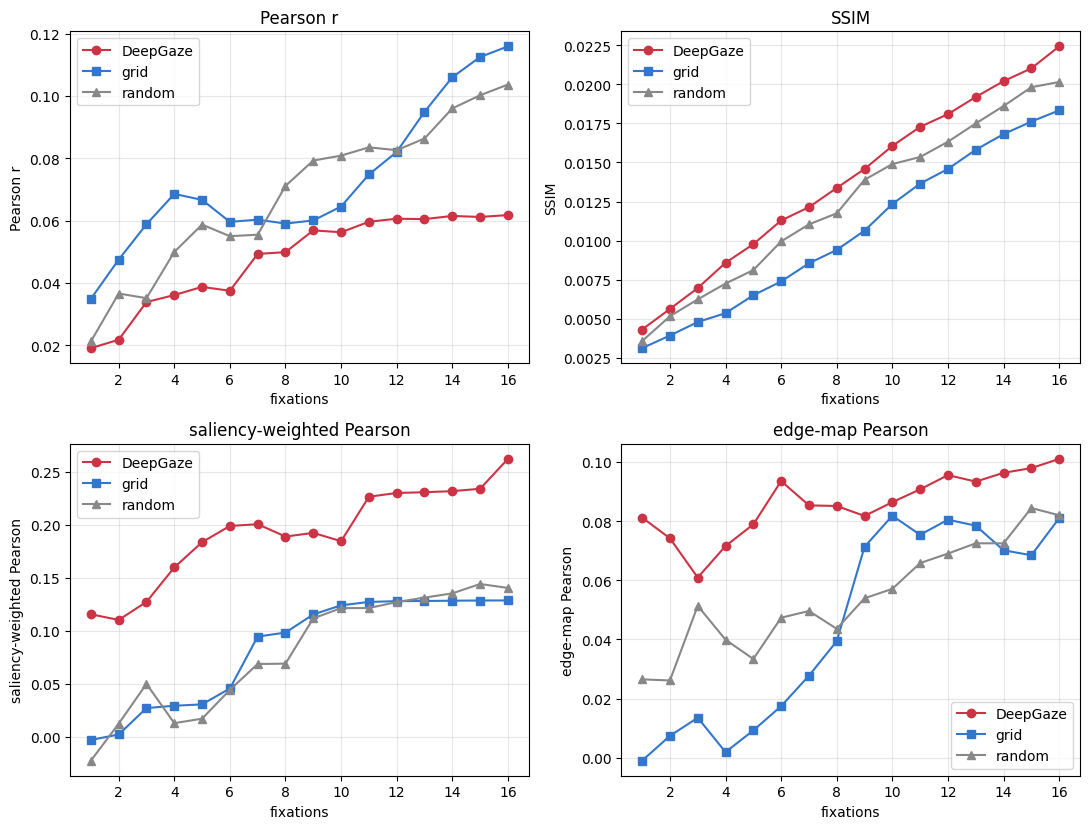

In [70]:
# Exercise 4.3 — perceptual reconstruction metrics

# Two metrics that try to weight the things a perceiver actually cares about:
# (1) where the salient content is, and (2) whether contour structure survives.

def saliency_weighted_pearson(reconstruction, target, saliency):
    '''Pearson r where each pixel contributes proportionally to its saliency.
    A reconstruction that fills in salient regions scores high; one that fills
    in unimportant areas doesn't, even if global brightness correlates fine.'''
    w = saliency.astype(np.float64).ravel()
    w = w / max(w.sum(), 1e-12)
    a = reconstruction.astype(np.float64).ravel()
    b = target.astype(np.float64).ravel()
    if a.max() > 0:
        a = a / a.max()
    if b.max() > 0:
        b = b / b.max()
    ma = (w * a).sum(); mb = (w * b).sum()
    da = a - ma; db = b - mb
    cov = (w * da * db).sum()
    var_a = (w * da ** 2).sum(); var_b = (w * db ** 2).sum()
    return float(cov / np.sqrt(var_a * var_b)) if var_a > 0 and var_b > 0 else 0.0

def edge_pearson(reconstruction, target):
    '''Pearson r between Sobel edge maps. Penalises losing contour structure —
    two images with the same per-pixel correlation can still have very different
    shapes, edge_pearson notices that.'''
    def edges(img):
        img = img.astype(np.float32)
        if img.max() > 0:
            img = img / img.max()
        gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
        return np.hypot(gx, gy)
    ea = edges(reconstruction).ravel()
    eb = edges(target).ravel()
    return float(np.corrcoef(ea, eb)[0, 1])

# Saliency = DeepGaze probability map of the original scene. Recompute so the
# cell is self-contained (it's the same `prob` from §1, modulo kernel state).
log_d_bus = deepgaze_density(bus_t, cb_t)
sal_bus = np.exp(log_d_bus); sal_bus /= sal_bus.sum()

def perceptual_curves(hist):
    sw, ep = [], []
    for c in hist:
        sw.append(saliency_weighted_pearson(c, bus_gray, sal_bus))
        ep.append(edge_pearson(c, bus_gray))
    return np.array(sw), np.array(ep)

sw_dg, ep_dg = perceptual_curves(hist_dg)
sw_gr, ep_gr = perceptual_curves(hist_grid)
sw_rn, ep_rn = perceptual_curves(hist_random)

x_axis = np.arange(1, N_FIX + 1)
fig, axes = plt.subplots(2, 2, figsize=(11, 8.4))
panels = [
    (p_dg,  p_gr,  p_rn,  'Pearson r',                 axes[0, 0]),
    (s_dg,  s_gr,  s_rn,  'SSIM',                      axes[0, 1]),
    (sw_dg, sw_gr, sw_rn, 'saliency-weighted Pearson', axes[1, 0]),
    (ep_dg, ep_gr, ep_rn, 'edge-map Pearson',          axes[1, 1]),
]
for dg, gr, rn, title, ax in panels:
    ax.plot(x_axis, dg, '-o', label='DeepGaze', color='#cc3344')
    ax.plot(x_axis, gr, '-s', label='grid',     color='#3377cc')
    ax.plot(x_axis, rn, '-^', label='random',   color='#888888')
    ax.set_xlabel('fixations'); ax.set_ylabel(title); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Reading the panels:
#   · Pearson r is gentle on random — even sky-pixel "wins" raise the score, so
#     uniform sampling catches up to DeepGaze faster than it should.
#   · Saliency-weighted Pearson concentrates the score on the bus front and
#     pedestrians. DeepGaze's early-fixation advantage is much bigger here
#     because it spends its first few saccades exactly there.
#   · Edge-map Pearson asks whether contours survive. Grid does well by N=12+
#     because it tiles the image; DeepGaze gets there faster because it biases
#     toward content-rich edges; random is the worst.
#   · SSIM falls between Pearson and the perceptual metrics — locally structure-
#     aware, but unaware of which structures matter to a viewer.

### Exercise 4.4 — does DeepGaze's advantage scale with bandwidth? `[challenge]`

Re-run the three-strategy comparison at 100, 500, and 1000 electrodes, **and score
every combination with all four metrics from Exercise 4.3** (Pearson r, SSIM,
saliency-weighted Pearson, edge-map Pearson). The naïve hypothesis: with very few
electrodes, gaze prediction matters less (you can't render anything well anyway);
in the middle, DeepGaze wins clearly; at very high counts, even a random sampler
converges because every saccade adds substantial information.

Does that pattern hold equally under every metric, or do the perceptual metrics
tell a different story about *when* DeepGaze actually helps?

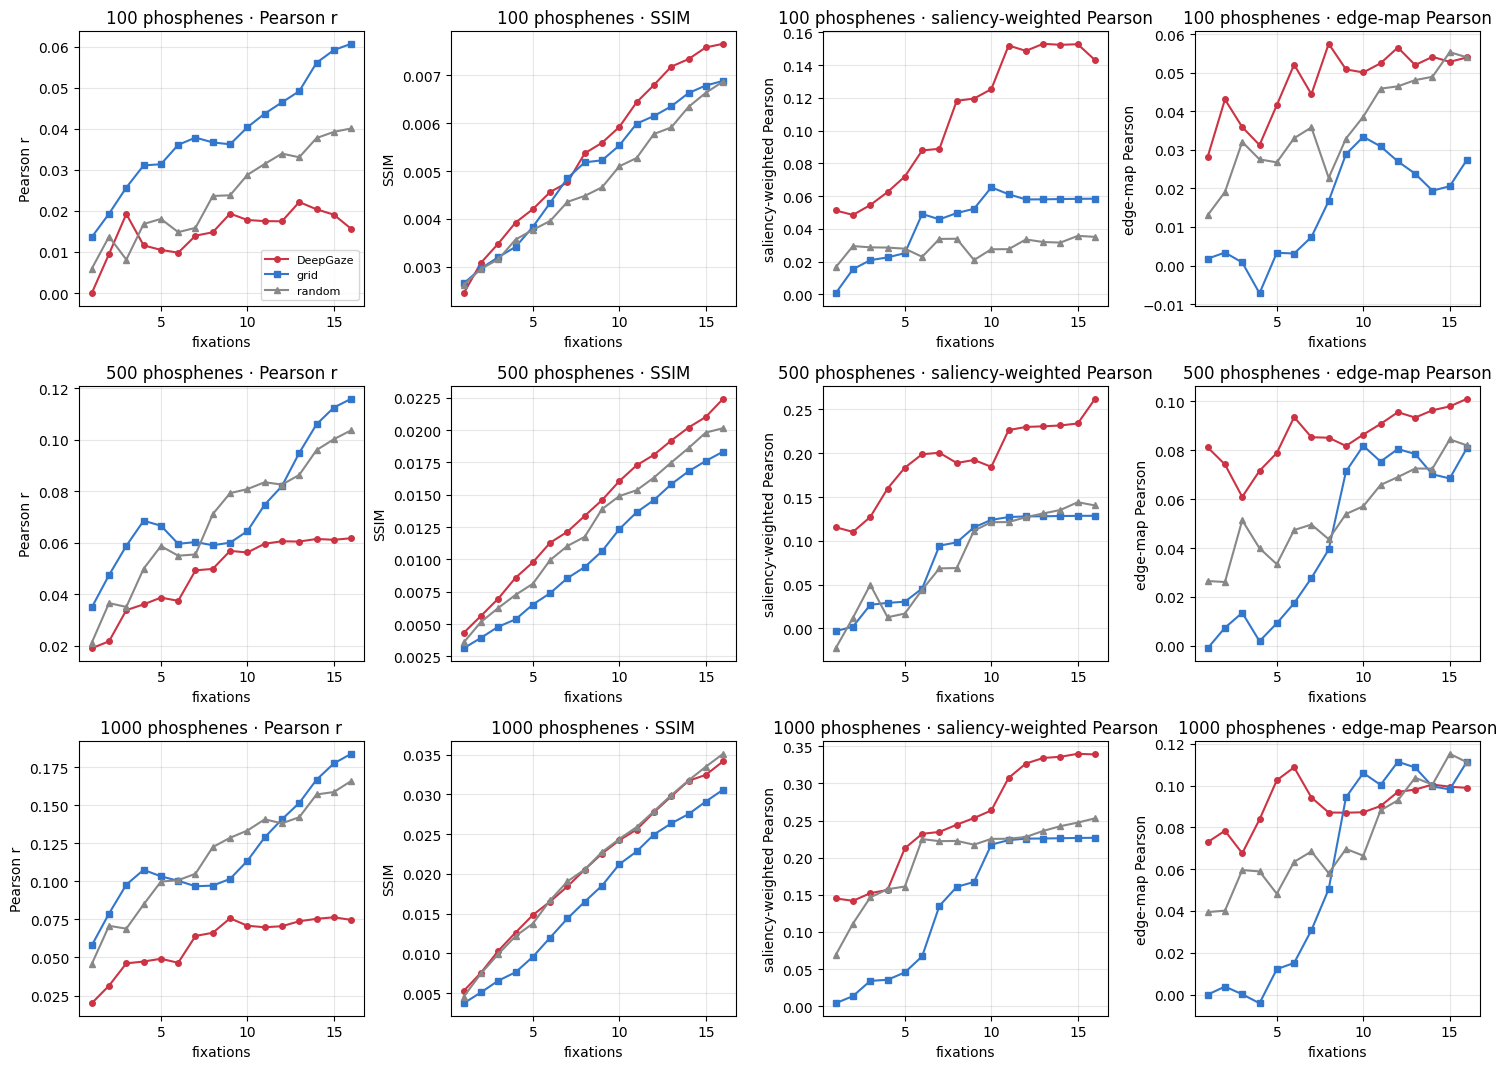

In [71]:
# Exercise 4.4 — DeepGaze vs random vs grid, sweeping electrode count, all four metrics

n_phos_list = [100, 500, 1000]

# Reuse the same scanpath per strategy across electrode counts — what changes
# between columns is the simulator, not the path.
grid_scan = grid_scanpath(H, W, N_FIX)
rand_scan = random_scanpath(H, W, N_FIX, seed=3)

def all_metric_curves(hist):
    '''Stack Pearson, SSIM, saliency-weighted Pearson, edge-map Pearson for one history.'''
    p_arr, s_arr   = curves(hist)              # from §4b
    sw_arr, ep_arr = perceptual_curves(hist)   # from Ex 4.3
    return p_arr, s_arr, sw_arr, ep_arr

metric_data = {}   # (n_phosphenes, strategy) -> (Pearson, SSIM, sw-Pearson, edge-Pearson)
for n in n_phos_list:
    sim_n = make_simulator(n_phosphenes=n, seed=0)
    for key, scan in [('dg', dg_path), ('grid', grid_scan), ('rand', rand_scan)]:
        hist_n = walk(bus_gray, scan, sim_n, fov_radius=56)
        metric_data[(n, key)] = all_metric_curves(hist_n)

metric_titles = ['Pearson r', 'SSIM', 'saliency-weighted Pearson', 'edge-map Pearson']
strategies = [('dg',   'DeepGaze', '-o', '#cc3344'),
              ('grid', 'grid',     '-s', '#3377cc'),
              ('rand', 'random',   '-^', '#888888')]

# 3 × 4 grid: rows = electrode count, columns = metric.
fig, axes = plt.subplots(len(n_phos_list), 4, figsize=(15, 3.6 * len(n_phos_list)))
x_axis = np.arange(1, N_FIX + 1)
for i, n in enumerate(n_phos_list):
    for j, title in enumerate(metric_titles):
        ax = axes[i, j]
        for key, label, style, color in strategies:
            ax.plot(x_axis, metric_data[(n, key)][j], style,
                    label=label, color=color, ms=4)
        ax.set_xlabel('fixations'); ax.set_ylabel(title)
        ax.set_title(f'{n} phosphenes · {title}')
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc='lower right')
        ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Reading the grid:
#   · 100 phosphenes (top row): everything is bandwidth-limited; the strategies sit close
#     together because no scanpath can extract much through that bottleneck.
#   · 500 phosphenes (middle): the sweet spot. DeepGaze's early-fixation lead is visible
#     under Pearson, more pronounced under saliency-weighted Pearson (which doesn't
#     reward grid/random hits on the sky), and stays noticeable under edge-map Pearson
#     where DeepGaze biases toward high-contrast contours first.
#   · 1000 phosphenes (bottom row): the gap shrinks under plain Pearson — random
#     coverage now resolves enough of the image to catch up. But the perceptual metrics
#     still favour DeepGaze early on; even at high bandwidth, salient regions fill in
#     much faster when attention is informed than when it's uniform.

## 5 · Challenges  *(open-ended; lighter scaffolding)*

Two open extensions. No worked solutions in the markdown — try them yourself, and the
solution notebook just shows one possible answer per challenge.

### 5.1 — A task-dependent prior with open-vocabulary detection `[challenge]`

The Center Bias you have used so far is a *task-free* prior: it encodes "people tend to look
near the middle of an image" regardless of *why* they are looking. But human gaze is famously
**task-dependent** — Yarbus (1967) showed the same scene scanned completely differently under
"estimate the people's ages" vs "guess what they were doing before the visitor arrived".
DeepGaze bakes this in cleanly: the `centerbias` argument is just a spatial log-prior added to
the model's saliency, so you can replace it with *any* prior you like — including one that
encodes a **task**.

Build a **task prior** and use it to simulate goal-directed **visual search**.

1. **Pick a search task** and express it as a short list of target keywords, e.g.
   `task = "find the people waiting for the bus"` → `["person", "backpack", "bus door"]`.
2. **Localise the targets** with an *open-vocabulary* detector. Unlike the COCO-locked
   `yolov8n-seg` from M1, **YOLO-World** accepts free-text class names — no retraining — so you
   can search for whatever your task names.
3. **Turn the detections into a spatial prior**: drop a Gaussian bump at each matching
   detection (weighted by confidence), blur it, and normalise to a log-density that sums to 1
   — exactly the format `build_centerbias()` returns.
4. **(Optional) blend** with the MIT1003 Center Bias (e.g. `0.7 * task + 0.3 * cb`) so the
   periphery isn't completely dead.
5. **Feed it in place of `cb_t`** to `sample_scanpath()` and plot the task-driven scanpath next
   to a free-viewing one (same seed). Does gaze now concentrate on the task-relevant objects?

**Resources you'll need**

- **Open-vocabulary model:** `yolov8s-world.pt` (~50 MB, auto-downloads on first use) from the
  `ultralytics` package. The gaze setup cell does not install `ultralytics`, so add it first
  (Colab-aware, like the setup cell):
  ```python
  import sys, subprocess
  subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                  *([] if "google.colab" in sys.modules else ["--user"]), "ultralytics"], check=True)
  from ultralytics import YOLO
  ov = YOLO("yolov8s-world.pt")
  ov.set_classes(["person", "backpack", "bus door"])   # any free text, not just COCO
  ```
  YOLO wants a **BGR** numpy array, so detect with `cv2.cvtColor(bus_rgb, cv2.COLOR_RGB2BGR)`.
- **Already in your kernel:** `build_centerbias`, `deepgaze_density`, `sample_scanpath`,
  `plot_scanpath`, `prob_norm`, `logsumexp`, `cb` / `cb_t`, and `bus_rgb` / `bus_t`.
- **Background:** Yarbus, *Eye Movements and Vision* (1967); Koehler et al. (2014),
  *What do saliency models predict?* — on task vs free-viewing fixations.

In [ ]:
# 5.1 — Task-dependent prior from open-vocabulary detection (YOLO-World)
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                *([] if 'google.colab' in sys.modules else ['--user']), 'ultralytics'], check=True)
from ultralytics import YOLO
from scipy.ndimage import gaussian_filter

# 1) A search task, expressed as open-vocabulary keywords --------------------------
TASK = 'find the people waiting for the bus'
TASK_CLASSES = ['person', 'backpack', 'bus door']

# 2) Open-vocabulary detection (YOLO-World accepts free text; no retraining) -------
ov = YOLO('yolov8s-world.pt')                 # ~50 MB, downloads on first run
ov.set_classes(TASK_CLASSES)
det = ov.predict(cv2.cvtColor(bus_rgb, cv2.COLOR_RGB2BGR), verbose=False)[0]
boxes = det.boxes.xyxy.cpu().numpy()
confs = det.boxes.conf.cpu().numpy()
print(f'task: "{TASK}"  ->  {len(boxes)} target detections for {TASK_CLASSES}')

# 3) Detections -> spatial log-prior (same format build_centerbias returns) --------
def task_prior(boxes, confs, h, w, sigma=14, floor=1e-4):
    heat = np.full((h, w), floor, dtype=np.float64)
    for (x0, y0, x1, y1), c in zip(boxes, confs):
        cy, cx = int((y0 + y1) / 2), int((x0 + x1) / 2)
        if 0 <= cy < h and 0 <= cx < w:
            heat[cy, cx] += float(c)
    heat = gaussian_filter(heat, sigma=sigma) + floor
    logp = np.log(heat); logp -= logsumexp(logp)      # exp(logp).sum() == 1
    return logp

# 4) Blend with the MIT1003 center bias so the periphery isn't completely dead -----
if len(boxes):
    BLEND = 0.7                                        # weight on the task prior
    mix = BLEND * np.exp(task_prior(boxes, confs, H, W)) + (1 - BLEND) * np.exp(cb)
else:                                                  # no detections -> fall back to CB
    print('no targets found; falling back to the center bias'); mix = np.exp(cb)
task_log = np.log(mix); task_log -= logsumexp(task_log)
task_cb_t = torch.tensor(task_log[None].astype(np.float32)).to(device)

# 5) Scanpath under the task prior vs free viewing (same seed) ---------------------
free_path, free_dens = sample_scanpath(bus_t, cb_t,      n_fix=12, seed=0)
task_path, task_dens = sample_scanpath(bus_t, task_cb_t, n_fix=12, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.4))
axes[0].imshow(bus_rgb)
axes[0].imshow(np.exp(task_log), cmap='magma', norm=prob_norm(np.exp(task_log)), alpha=0.6)
for (x0, y0, x1, y1) in boxes:
    axes[0].add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, color='cyan', lw=1.5))
axes[0].set_title(f'task prior (log color)\n{TASK_CLASSES}'); axes[0].axis('off')
plot_scanpath(bus_rgb, free_path, free_dens[-1], ax=axes[1], title='free viewing (MIT1003 CB)')
plot_scanpath(bus_rgb, task_path, task_dens[-1], ax=axes[2], title=f'task-driven: "{TASK}"')
plt.tight_layout(); plt.show()

print('Under the task prior the scanpath is pulled onto the detected targets;')
print('free viewing also wanders to whatever is most salient (the bus front).')

### 5.2 — Motor jitter `[challenge]`

Real human fixations are noisy — the eye does not land exactly where it intended. Add
Gaussian noise (sd ~ 4 pixels, the order of typical microsaccades) to each DeepGaze-sampled
fixation *before* you pass it to `foveate()`. How much does this degrade the cumulative
Pearson correlation curve?

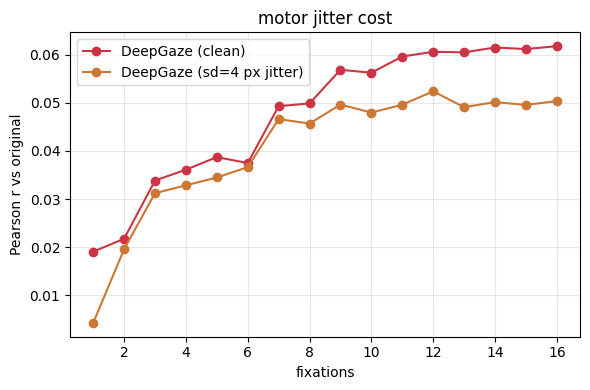

In [62]:
# 5.2 — DeepGaze with motor jitter
def jittered_scanpath(scanpath, sd=4.0, seed=0):
    rng = np.random.default_rng(seed)
    return [(int(np.clip(p[0] + rng.normal(0, sd), 0, W - 1)),
             int(np.clip(p[1] + rng.normal(0, sd), 0, H - 1))) for p in scanpath]

clean = sample_scanpath(bus_t, cb_t, n_fix=N_FIX, seed=7)[0]
jittered = jittered_scanpath(clean, sd=4.0, seed=11)
sim_j = make_simulator(n_phosphenes=500, seed=0)
p_clean, _ = cumulative_similarity(clean,    bus_gray, sim_j)
p_jitter, _ = cumulative_similarity(jittered, bus_gray, sim_j)

plt.figure(figsize=(6, 4))
x_axis = np.arange(1, N_FIX + 1)
plt.plot(x_axis, p_clean,  '-o', label='DeepGaze (clean)', color='#cc3344')
plt.plot(x_axis, p_jitter, '-o', label='DeepGaze (sd=4 px jitter)', color='#cc7733')
plt.xlabel('fixations'); plt.ylabel('Pearson r vs original'); plt.legend(); plt.grid(alpha=0.3)
plt.title('motor jitter cost')
plt.tight_layout(); plt.show()

## Where to next

You've now done end-to-end what the HTML page laid out conceptually:

- Run DeepGaze III on real images and produced heatmaps that match human attention.
- Sampled scanpaths and recovered the same saccade-length and saccade-angle distributions
  the HTML page synthesised from literature.
- Plugged gaze into the real `dynaphos` simulator and watched the **sliding effect** appear
  and disappear depending on whether the renderer is gaze-contingent.
- **Quantified** how much gaze prediction is worth: with informed sampling, ~5 well-chosen
  fixations match what ~10 random ones cover.

Next module: **M3 — Neuromodulation & stimulation**, where the patch of scene you just
decided to look at becomes an actual stimulation pattern across the electrodes you saw
`dynaphos` simulate here.